# LangGraph를 이용한 StateGraph 기본

## 학습 목표
- LangGraph의 StateGraph를 이해하고 구축하기
- 그래프 노드(Node)와 엣지(Edge) 연결하기
- 상태(State) 기반 워크플로우 실행하기
- 그래프 시각화 및 호출(invoke) 메서드 사용하기

## 사전 설치 패키지
- langgraph: LangGraph 라이브러리


In [ ]:
# pip install -U langgraph

### Step 1. 필요한 라이브러리 임포트

LangGraph에서 StateGraph, 그래프의 시작점(START), 끝점(END)을 임포트합니다.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

### Step 2. 그래프 상태(State) 정의

TypedDict를 사용하여 그래프에서 사용할 상태 객체를 정의합니다.

- count: 카운터 값
- msg: 상태 메세지

In [2]:
class MyGraphState(TypedDict):
    """그래프에서 사용할 상태 정의"""
    count: int
    msg: str

### Step 3. 노드 함수 정의

각 노드에서 실행될 함수를 정의합니다. 이 함수는 상태를 입력받아 수정하고 반환합니다.

counter 함수를 통해서 "각 노드가 이전 노드의 결과(state)를 이어받아서 누적시킨다"는 사실을 확인 가능하다.

In [3]:
def counter(state: MyGraphState):
    """카운터를 증가시키는 노드 함수"""
    state["count"] += 1
    state["msg"] = f"Counter function has been called {state['count']} time(s)"
    return state

### Step 4. StateGraph 생성 및 노드 추가

StateGraph 객체를 생성하고, 실행할 노드들을 추가합니다.

In [5]:
workflow = StateGraph(MyGraphState)

# 3개의 노드를 그래프에 추가
# 각 노드는 counter 함수를 실행함
workflow.add_node("Node1", counter)
workflow.add_node("Node2", counter)
workflow.add_node("Node3", counter)

### Step 5. 노드 연결 (엣지 정의)

노드들 간의 실행 흐름을 정의합니다.

START -> Node1 -> Node2 -> Node3 -> END 순서로 실행됩니다.

In [6]:
# START에서 Node1로 시작
workflow.add_edge(START, "Node1")

# 노드 간 순차 연결
workflow.add_edge("Node1", "Node2")
workflow.add_edge("Node2", "Node3")

# Node3에서 END로 종료
workflow.add_edge("Node3", END)

### Step 6. 그래프 컴파일

정의된 워크플로우를 컴파일하여 실행 가능한 상태로 변환합니다.

In [7]:
app = workflow.compile()

### Step 7. 그래프 시각화

Mermaid 형식으로 그래프 구조를 시각화하여 노드와 엣지의 연결 관계를 확인합니다.

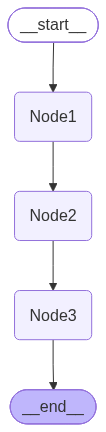

In [8]:
from IPython.display import Image, display

# 그래프를 Mermaid 다이어그램으로 렌더링
png = app.get_graph().draw_mermaid_png()
display(Image(png))

### Step 8. 그래프 실행

초기 상태를 설정하여 그래프를 실행합니다.

START → Node1 → Node2 → Node3 → END 순서로 실행되며,
각 노드에서 counter 함수가 실행되어 count가 증가합니다.

In [10]:
# 초기 상태 설정: count=0, msg="hello"
# invoke 메서드로 그래프 실행

result = app.invoke({"count": 0, "msg": "hello"})
print(f"최종 결과: {result}")

최종 결과: {'count': 3, 'msg': 'Counter function has been called 3 time(s)'}


## 핵심 정리

| 개념 | 설명 |
|------|------|
| **StateGraph** | 노드와 엣지를 기반으로 워크플로우를 정의하는 클래스 |
| **노드(Node)** | 특정 작업을 수행하는 함수 또는 로직 |
| **엣지(Edge)** | 노드 간의 연결 관계, 실행 흐름 정의 |
| **상태(State)** | 노드 간에 공유되는 데이터를 정의하는 TypedDict |
| **START/END** | 그래프의 시작점과 끝점 |
| **invoke()** | 그래프를 실행하는 메서드 |
| **compile()** | 워크플로우를 실행 가능한 형태로 변환 |

### 실행 흐름
1. START → Node1 (count: 0 → 1)
2. Node1 → Node2 (count: 1 → 2)
3. Node2 → Node3 (count: 2 → 3)
4. Node3 → END

## LLM을 사용한 간단한 챗봇을 StateGraph로 구현하기

### 0. 환경 변수 설정하기

In [11]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY가 설정되지 않았습니다."

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
print("LLM 준비 완료")

LLM 준비 완료


### 1. 상태(State) 정의

In [12]:
from typing import Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    """챗봇용 상태 정의"""
    messages: Annotated[list, add_messages] # add_messages가 응답을 자동으로 누

### 2. 노드(Node) 정의

- LLM 모델 객체 생성하고 실행하기 (.invoke())

In [14]:
def chatbot(state: ChatState) -> dict:
    """LLM을 호출해서 응답 메세지를 생성하는 노드 함수"""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

### 3. 그래프(Graph) 정의

In [15]:
graph_builder = StateGraph(ChatState)

### 4. 노드 추가

- chatbot 노드 함수: 현재 State를 입력으로 받아 'messages'라는 키 아래에 업데이트된 messages 목록을 포함하는 사전(TypedDict)을 반환

- State의 add_messages 함수는 이미 상태에 있는 메세지에 llm의 응답 메세지를 추가함

In [16]:
graph_builder.add_node("chatbot", chatbot)

### 5. 그래프 엣지(Edge) 추가

- START: 그래프가 실행될 때마다 작업을 시작할 위치
- END: 그래프 프름의 종료(끝지점)

In [17]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

### 6. 그래프 컴파일 (Compile)

- 그래프 빌더에서 'compile()'을 호출하면 상태에서 호출할 수 있는 'CompiledGraph'가 생성됨

In [18]:
graph = graph_builder.compile()

### 7. 그래프 시각화 (optional)

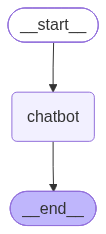

In [19]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"시각화 실패: {e}")

## 8. 그래프 실행 - Chatbot
- LangGraph에서 워크플로우를 실행하는 두 가지 방식
1. graph.invoke() : "한 번에 실행 → 최종 결과만 반환"
    - 전체 워크플로우를 순차적으로 실행한 뒤 최종 결과만 한 번에 반환
    - 내부적으로 어떤 노드가 언제 실행되었는지, 중간 단계는 보이지 않음
    - 매우 간단하고 직관적임
    - 결과만 있으면 되는 경우

2. graph.stream() : "노드 단위 이벤트 스트리밍"
    - 워크플로우의 각 노드가 실행될 때마다 이벤트를 생성해서 순차적으로 반환
    - 각 이벤트는 {"노드이름": {"messages": [...]}} 구조
    - 최종 결과가 아니라, 중간 상태, 노드 이름, 메시지 변경 등을 실시간으로 관찰 가능
    - 중간 노드들의 결과를 실시간으로 확인하고 싶을 때
    - LLM 응답이 나오는 동안 토큰이 하나씩 출력되는 방식은 아님
    - 응답
        ```python
        event = {
            'chatbot': {
                'messages': [AIMessage(content='안녕하세요! 만나서 반가워요. 어떻게 도와드릴까요?', ...)]
            }
        }
        ```

- invoke() 사용

In [21]:
result = graph.invoke({"messages": [{"role": "user", "content": "안녕하세요! 자기소개 부탁해요."}]})
print(result["messages"][-1].content)

안녕하세요! 저는 AI 언어 모델로, 다양한 질문에 답하고 정보를 제공하는 역할을 하고 있습니다. 여러 주제에 대해 대화할 수 있으며, 여러분의 궁금증을 해결하는 데 도움을 드리고자 합니다. 무엇을 도와드릴까요?


- stream() 사용

In [22]:
for event in graph.stream({"messages": [{"role": "user", "content": "LangGraph가 뭔가요?"}]}):
    for node_name, value in event.items():
        print(f"[{node_name}]")
        print(value["messages"][-1].content)

[chatbot]
LangGraph는 자연어 처리(NLP)와 관련된 기술이나 도구를 지칭하는 용어일 수 있습니다. 그러나 "LangGraph"라는 이름의 특정한 프로젝트나 기술에 대한 정보는 제 데이터베이스에 포함되어 있지 않습니다. 

일반적으로, "Lang"는 언어(Language)를 의미하고, "Graph"는 그래프(Graph) 구조를 의미할 수 있습니다. 따라서 LangGraph는 언어 데이터를 그래프 형태로 표현하거나, 언어와 관련된 다양한 관계를 시각화하는 도구일 가능성이 있습니다.

더 구체적인 정보나 맥락이 필요하다면, LangGraph에 대한 추가적인 세부사항을 제공해 주시면 더 도움을 드릴 수 있을 것 같습니다.


In [24]:
# 멀티턴 테스트: 이전 대화 메시지를 이어서 전달하면 맥락을 기억하는지 확인
messages = [{"role": "user", "content": "내 이름은 지수야."}]
result = graph.invoke({"messages": messages})
print("챗봇:", result["messages"][-1].content)

messages = result["messages"] + [{"role": "user", "content": "내 이름이 뭐라고 했지?"}]
result = graph.invoke({"messages": messages})
print("챗봇:", result["messages"][-1].content)

챗봇: 안녕하세요, 지수님! 만나서 반갑습니다. 어떻게 도와드릴까요?
챗봇: 당신의 이름은 지수라고 하셨습니다. 맞나요?
